# MNIST Adversarial Attacks with PyTorch

An adversarial example is an instance with small feature perturbations that cause a machine learning model to make a wrong prediction. This notebook studies random-noise and gradient-based adversarial examples on MNIST while preserving the original experimental progression, code style, comments, and saved results.


In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix,mean_squared_error,mean_absolute_error
import time
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.datasets as dsets
from torch.utils.data import DataLoader
from torchvision.transforms import ToTensor
from torch.autograd import Variable

In [2]:
def plot_results(history):
  fig, ax = plt.subplots(ncols=2, figsize=(12,4))
  ax[0].plot(history['accuracy'],label = 'train')
  ax[0].plot(history['val_accuracy'],label = 'test')
  ax[0].set_title('Accuracy')
  ax[0].legend(loc='lower right')
  ax[0].grid(True)
  ax[1].plot(history['loss'],label = 'train')
  ax[1].plot(history['val_loss'],label = 'test')
  ax[1].set_title('Loss')
  ax[1].legend(loc='upper right')
  ax[1].grid(True)

# MNIST Dataset

We will train a simple model to classify the MNIST dataset. Then we will see how we can modify input data to force the model to misclassify test examples.


In [3]:
import tensorflow as tf
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()
X_train = np.float32(X_train.reshape(X_train.shape[0],-1))/255
X_test = np.float32(X_test.reshape(X_test.shape[0],-1))/255
y_train_oh = np.float32(tf.keras.utils.to_categorical(y_train, 10))
y_test_oh = np.float32(tf.keras.utils.to_categorical(y_test, 10))
print(f'{X_train.shape=}')
print(f'{X_test.shape=}')
print(f'{y_train.shape=}')
print(f'{y_test.shape=}')
print(f'{y_train_oh.shape=}')
print(f'{y_test_oh.shape=}')


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
X_train.shape=(60000, 784)
X_test.shape=(10000, 784)
y_train.shape=(60000,)
y_test.shape=(10000,)
y_train_oh.shape=(60000, 10)
y_test_oh.shape=(10000, 10)


In [4]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cuda device


In [5]:
X_train_t = torch.tensor(X_train).to(device)
y_train_oh_t = torch.tensor(y_train_oh).to(device)
X_test_t = torch.tensor(X_test).to(device)
y_test_oh_t = torch.tensor(y_test_oh).to(device)

Extract a list of images belonging to each class. *sample[i]* contains a list with the indices of all images of class *i*.


In [6]:
sample = [[] for i in range(10)]
for i,y in enumerate(y_test):
  sample[y].append(i)

## Feed-Forward Classification Baseline


ffnn(
  (dense1): Linear(in_features=784, out_features=500, bias=True)
  (dense2): Linear(in_features=500, out_features=10, bias=True)
)
Epoch  1 loss = 0.502874 test loss = 0.256346 train accuracy = 0.8710 test accuracy = 0.9264 
Epoch  2 loss = 0.217415 test loss = 0.177940 train accuracy = 0.9383 test accuracy = 0.9476 
Epoch  3 loss = 0.156960 test loss = 0.138771 train accuracy = 0.9554 test accuracy = 0.9592 
Epoch  4 loss = 0.120723 test loss = 0.116712 train accuracy = 0.9657 test accuracy = 0.9649 
Epoch  5 loss = 0.096743 test loss = 0.100409 train accuracy = 0.9725 test accuracy = 0.9696 
Epoch  6 loss = 0.080224 test loss = 0.087628 train accuracy = 0.9771 test accuracy = 0.9727 
Epoch  7 loss = 0.066832 test loss = 0.081227 train accuracy = 0.9810 test accuracy = 0.9751 
Epoch  8 loss = 0.055393 test loss = 0.076047 train accuracy = 0.9843 test accuracy = 0.9765 
Epoch  9 loss = 0.047500 test loss = 0.076027 train accuracy = 0.9871 test accuracy = 0.9766 
Epoch 10 loss = 0

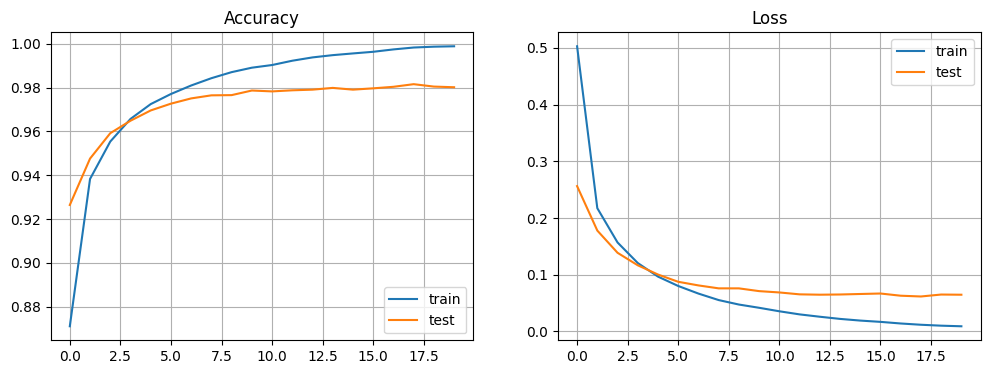

In [7]:
class ffnn(nn.Module):
  def __init__(self, n_inputs, n_hidden, n_outputs):
    super(ffnn,self).__init__()
    self.dense1 = nn.Linear(n_inputs, n_hidden)
    self.dense2 = nn.Linear(n_hidden, n_outputs)

  def forward(self,x):
    x = self.dense1(x)
    x = F.relu(x)
    x = self.dense2(x)
    return x

model = ffnn(784, 500,  10).to(device)
print(model)

loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 20
batch_size = 500
size = X_train.shape[0]
start_train = time.time()
loss_list, acc_list  = [], []
loss_list_tst, acc_list_tst  = [], []
n_batches = X_train.shape[0]//batch_size
for epoch in range(1,num_epochs+1):
  pred_train = np.zeros(size,dtype= np.int32)
  batch_num = np.random.permutation(size)//batch_size
  sum_loss = 0
  for i in range(n_batches):
    pred = model(X_train_t[batch_num==i])
    pred_train[batch_num==i] = np.argmax(pred.cpu().detach().numpy(),axis=1)
    loss = loss_function(pred, y_train_oh_t[batch_num==i])
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    sum_loss+=loss.item()

  loss_list.append(batch_size*sum_loss/size)
  acc_list.append(accuracy_score(y_train,pred_train))
  pred_test = model(X_test_t)
  loss_tst = loss_function(pred_test, y_test_oh_t).item()
  loss_list_tst.append(loss_tst)
  acc_list_tst.append(accuracy_score(y_test,np.argmax(pred_test.cpu().detach().numpy(),axis=1)))

  print(f'Epoch {epoch:2} loss = {loss_list[-1]:.6f} test loss = {loss_list_tst[-1]:.6f} train accuracy = {acc_list[-1]:.4f} test accuracy = {acc_list_tst[-1]:.4f} ')

end_train = time.time()
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
history = {'accuracy':acc_list, 'loss': loss_list, 'val_accuracy': acc_list_tst, 'val_loss': loss_list_tst}
plot_results(history)

# Generating adversarial examples adding random noise

As a baseline to compare other approaches, first we will just add random noise to the test images and see how the model's performance degrades.


**Idea:** add increasingly large random noise to the images in the test set and evaluate the accuracy of the model.

When the accuracy falls below a target accuracy (for example, 0.5), display some of the noisy images.


sigma = 0.0050, acc = 0.9802
sigma = 0.0100, acc = 0.9794
sigma = 0.0150, acc = 0.9799
sigma = 0.0200, acc = 0.9803
sigma = 0.0250, acc = 0.9800
sigma = 0.0300, acc = 0.9798
sigma = 0.0350, acc = 0.9799
sigma = 0.0400, acc = 0.9803
sigma = 0.0450, acc = 0.9799
sigma = 0.0500, acc = 0.9795
sigma = 0.0550, acc = 0.9794
sigma = 0.0600, acc = 0.9786
sigma = 0.0650, acc = 0.9781
sigma = 0.0700, acc = 0.9770
sigma = 0.0750, acc = 0.9765
sigma = 0.0800, acc = 0.9762
sigma = 0.0850, acc = 0.9759
sigma = 0.0900, acc = 0.9760
sigma = 0.0950, acc = 0.9765
sigma = 0.1000, acc = 0.9750
sigma = 0.1050, acc = 0.9738
sigma = 0.1100, acc = 0.9737
sigma = 0.1150, acc = 0.9722
sigma = 0.1200, acc = 0.9726
sigma = 0.1250, acc = 0.9731
sigma = 0.1300, acc = 0.9709
sigma = 0.1350, acc = 0.9711
sigma = 0.1400, acc = 0.9703
sigma = 0.1450, acc = 0.9676
sigma = 0.1500, acc = 0.9672
sigma = 0.1550, acc = 0.9649
sigma = 0.1600, acc = 0.9616
sigma = 0.1650, acc = 0.9615
sigma = 0.1700, acc = 0.9602
sigma = 0.1750

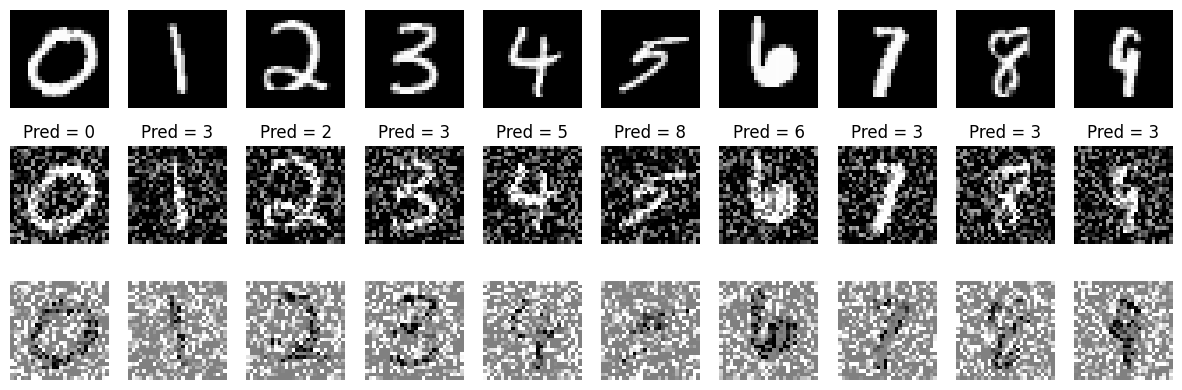

In [8]:
goal_acc = 0.5 # Exit loop when model accuracy on the adversarial data goes below this value
max_it = 200

for i in range(1,max_it):
  sigma = i/max_it # Sigma goes from 0.01 to 0.99 if max_it = 100
  noise = np.float32(np.random.uniform(-sigma, sigma, X_test.shape))
  X_test_noisy = np.clip(X_test+noise,0,1)
  pred = model(torch.tensor(X_test_noisy).to(device))
  pred_class = np.argmax(pred.cpu().detach().numpy(),axis=1)
  acc = accuracy_score(y_test,pred_class)
  print(f'{sigma =:7.4f}, {acc =:7.4f}')
  if acc < goal_acc:
     break

print('Confusion matrix')
print(confusion_matrix(y_test,pred_class))

rs = [np.random.randint(0,len(sample[i])) for i in range(10)]
random_sel = [sample[i][r] for i,r in enumerate(rs)]
noise = X_test_noisy - X_test
print(f'Mean absolute noise = {np.mean(np.abs(noise)) :7.4f}')
print(f'Max absolute noise = {np.max(np.abs(noise)) :7.4f}')

fig, ax = plt.subplots(3, 10, figsize=(15,5))
for i,s in enumerate(random_sel):
  ax[0,i].imshow(X_test[s].reshape(28,28), vmin=0, vmax=1, cmap = "gray")
  ax[0,i].axis("off")
  ax[1,i].imshow(X_test_noisy[s].reshape(28,28), vmin=0, vmax=1, cmap = "gray")
  ax[1,i].axis("off")
  ax[1,i].set_title(f'Pred = {pred_class[s]}')
  ax[2,i].imshow(noise[s].reshape(28,28),  vmin=-.5, vmax=.5, cmap = "gray")
  ax[2,i].axis("off")


As can be seen, we need a fairly large amount of noise to fool the network. In the next section we'll show how using gradient information we can generate adversarial images with much less noise added.


# Using gradient information to generate adversarial examples


Recall that in a computation graph, we can compute the gradient of a node with respect to any ancestor node, including the input. Thus we can compute the gradient of the loss with respect to the input and then modify the input in a way that INCREASES the loss.


## The Fast Gradient Sign Method (FGSM)


First, we create a tensor with the test data but set the requires_grad flag to True, since we will be using this gradient.


In [9]:
X_test_gr = torch.tensor(X_test).to(device).requires_grad_(True)

Now we feed the data to the network and find the gradient of the loss with respect to the input.

Recall that the gradient of a parameter tells us how a change in that parameter changes the loss.


In [10]:
pred = model(X_test_gr)
loss = loss_function(pred, y_test_oh_t)
loss.backward()

We now extract the sign of the gradient of the loss with respect to the input. Each element in the grad_sign tensor is equal to either 1 or -1, indicating whether increasing or decreasing it results in an increase in the loss.


In [11]:
grad = X_test_gr.grad.cpu().detach().numpy()
grad_sign = np.sign(grad)

Note that grad_sign has the same shape as X_test. We can visualize some images, their gradients, and  the sign of those gradients.


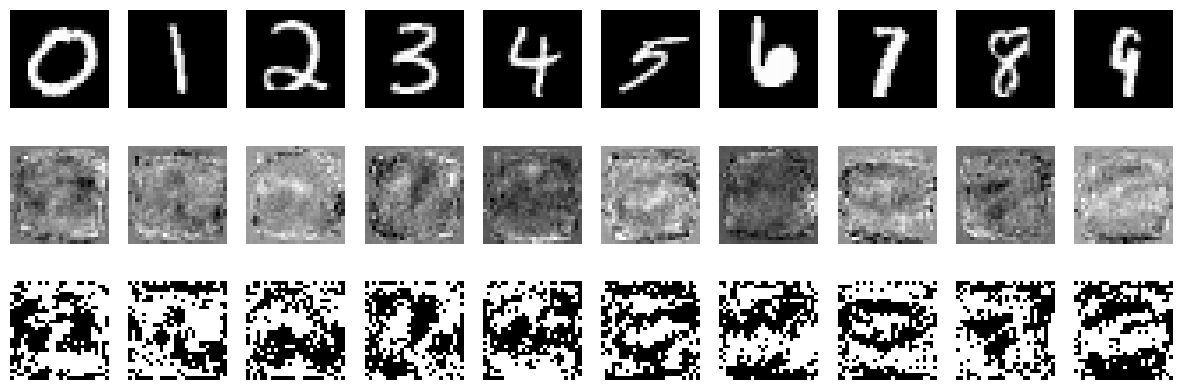

In [12]:
fig, ax = plt.subplots(3, 10, figsize=(15,5))
for i,s in enumerate(random_sel):
  ax[0,i].imshow(X_test[s].reshape(28,28), vmin=0, vmax=1, cmap = "gray")
  ax[0,i].axis("off")
  ax[1,i].imshow(grad[s].reshape(28,28),  cmap = "gray")
  ax[1,i].axis("off")
  ax[2,i].imshow(grad_sign[s].reshape(28,28),  cmap = "gray")
  ax[2,i].axis("off")

Now we multiply the gradient sign by a small constant to create adversarial noise, which is added to the input.

We keep increasing the constant until the model's accuracy of the model on the resulting noisy images falls below a threshold.


This method is known as the Fast Gradient Sign Method (FGSM). The complete code is as follows:


sigma = 0.0050, acc = 0.9704
sigma = 0.0100, acc = 0.9574
sigma = 0.0150, acc = 0.9369
sigma = 0.0200, acc = 0.9102
sigma = 0.0250, acc = 0.8688
sigma = 0.0300, acc = 0.8092
sigma = 0.0350, acc = 0.7258
sigma = 0.0400, acc = 0.6364
sigma = 0.0450, acc = 0.5386
sigma = 0.0500, acc = 0.4570
sigma = 0.0550, acc = 0.3846
sigma = 0.0600, acc = 0.3201
sigma = 0.0650, acc = 0.2717
sigma = 0.0700, acc = 0.2272
sigma = 0.0750, acc = 0.1877
sigma = 0.0800, acc = 0.1540
sigma = 0.0850, acc = 0.1275
sigma = 0.0900, acc = 0.1107
sigma = 0.0950, acc = 0.0953
Confusion matrix
[[231   0 254   3   3  72 250  18  41 108]
 [  0   0  69 156  27   4   9 244 622   4]
 [ 26  81 152 432  29   7  44  95 163   3]
 [  1   7 130 152   1 422   2  22 201  72]
 [  6  10  73  11  44  10  71  67 115 575]
 [ 12   5  14 364   5 101  63  11 259  58]
 [ 73   7 168  19 212 203 193   4  77   2]
 [  5  24 226 358  29  10   2  35  73 266]
 [ 23  15 229 385  25 131  53  13  39  61]
 [  7  11  29 157 383  49   5 139 223   6]]
M

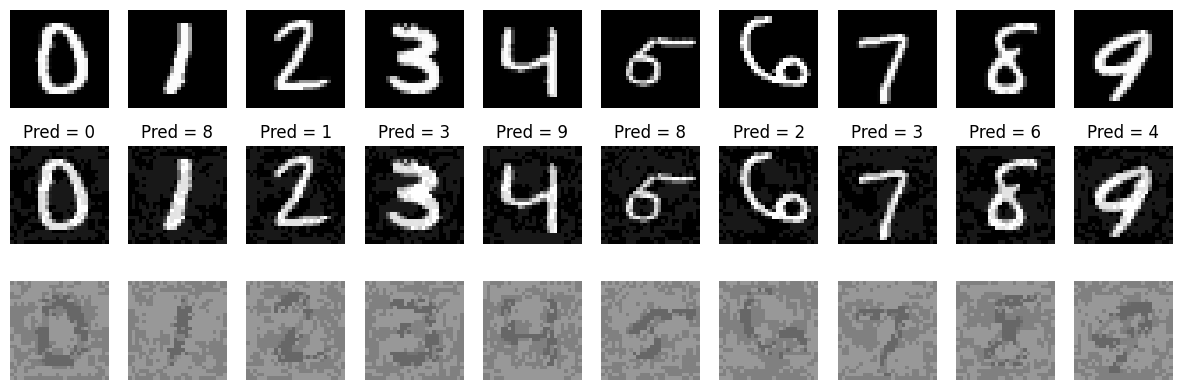

In [13]:
X_test_gr = torch.tensor(X_test).to(device).requires_grad_(True)
pred = model(X_test_gr)
loss = loss_function(pred, y_test_oh_t)
loss.backward()
grad = X_test_gr.grad.cpu().detach().numpy()
grad_sign = np.sign(grad)

goal_acc = 0.1 #  Exit loop when model accuracy on the adversarial data goes below this value
max_it = 200

for i in range(1,max_it):
  sigma = i/max_it # Sigma goes from 0.01 to 0.99 if max_it = 100
  noise = sigma*grad_sign
  X_test_noisy = np.clip(X_test+noise,0,1) # Keep input in the 0 to 1 range
  pred = model(torch.tensor(X_test_noisy).to(device))
  pred_class = np.argmax(pred.cpu().detach().numpy(),axis=1)
  acc = accuracy_score(y_test,pred_class)
  print(f'{sigma =:7.4f}, {acc =:7.4f}')
  if acc < goal_acc:
     break

print('Confusion matrix')
print(confusion_matrix(y_test,pred_class))

# Select a random image from each class to display
rs = [np.random.randint(0,len(sample[i])) for i in range(10)]
random_sel = [sample[i][r] for i,r in enumerate(rs)]
noise = X_test_noisy - X_test
print(f'Mean absolute noise = {np.mean(np.abs(noise)) :7.4f}')
print(f'Max absolute noise = {np.max(np.abs(noise)) :7.4f}')

fig, ax = plt.subplots(3, 10, figsize=(15,5))
for i,s in enumerate(random_sel):
  ax[0,i].imshow(X_test[s].reshape(28,28), vmin=0, vmax=1, cmap = "gray")
  ax[0,i].axis("off")
  ax[1,i].imshow(X_test_noisy[s].reshape(28,28), vmin=0, vmax=1, cmap = "gray")
  ax[1,i].axis("off")
  ax[1,i].set_title(f'Pred = {pred_class[s]}')
  ax[2,i].imshow(noise[s].reshape(28,28),  vmin=-.5, vmax=.5, cmap = "gray")
  ax[2,i].axis("off")

As you can see, the amount of noise required is much smaller than that obtained with random approaches, since the noise is carefully chosen to increase the loss.

It is possible to reduce accuracy to very low values, such as 0.1, while the resulting images are still easily classified correctly by a person.


### FGSM with targeted attacks

We can also target the noise to make the model predict a desired class for all images.

In this case, we modify the target (for example to predict '5' for all examples) and apply noise to decrease the loss for that target.


sigma = 0.0100, acc = 0.0927
sigma = 0.0200, acc = 0.1010
sigma = 0.0300, acc = 0.1168
sigma = 0.0400, acc = 0.1544
sigma = 0.0500, acc = 0.2160
sigma = 0.0600, acc = 0.3057
sigma = 0.0700, acc = 0.4084
sigma = 0.0800, acc = 0.5073
sigma = 0.0900, acc = 0.6006
sigma = 0.1000, acc = 0.6847
sigma = 0.1100, acc = 0.7524
sigma = 0.1200, acc = 0.8062
sigma = 0.1300, acc = 0.8504
sigma = 0.1400, acc = 0.8847
sigma = 0.1500, acc = 0.9117
Confusion matrix
[[  55    0    6    1    0  888   16    0   13    1]
 [   0    0    0    3    0  984    0    0  148    0]
 [   4    0   13   70    0  882   16    1   46    0]
 [   0    0    1    2    0 1005    0    0    2    0]
 [   0    0    1    1    0  840   14    0  118    8]
 [   0    0    0    0    0  892    0    0    0    0]
 [   0    0    0    3    2  911   31    0   11    0]
 [   0    0   12   25    0  843    2    0  146    0]
 [   0    0   13    1    0  941    0    0   19    0]
 [   0    0    3    1    0  931   11    0   63    0]]
Mean absolute noi

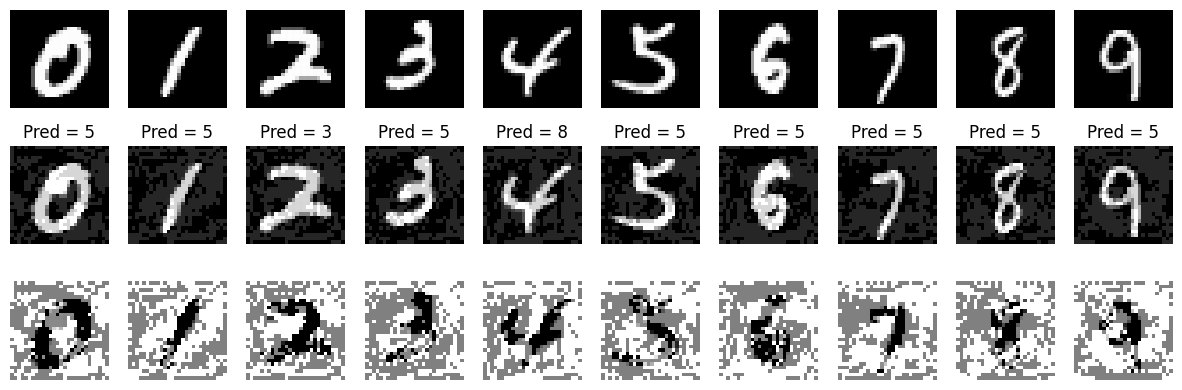

In [14]:
X_test_gr = torch.tensor(X_test).to(device).requires_grad_(True)
target_class = 5
goal_acc = 0.9

y_test_adv = np.zeros_like(y_test)
y_test_adv[:] = target_class
y_test_oh_adv = np.zeros_like(y_test_oh)
y_test_oh_adv[:,target_class] = 1

y_test_oh_adv_t = torch.tensor(y_test_oh_adv).to(device)

pred = model(X_test_gr)
loss = loss_function(pred, y_test_oh_adv_t)
loss.backward()
grad_sign = torch.sign(X_test_gr.grad).cpu().detach().numpy()

for i in range(1,100):
  sigma = i/100
  noise = -sigma*grad_sign
  X_test_noisy = np.clip(X_test+noise,0,1)
  pred = model(torch.tensor(X_test_noisy).to(device))
  pred_class = np.argmax(pred.cpu().detach().numpy(),axis=1)
  acc = accuracy_score(y_test_adv,pred_class)
  print(f'{sigma =:7.4f}, {acc =:7.4f}')
  if acc>goal_acc:
    break

print('Confusion matrix')
print(confusion_matrix(y_test,pred_class))

noise = X_test_noisy - X_test
print(f'Mean absolute noise = {np.mean(np.abs(noise)) :7.4f}')
print(f'Max absolute noise = {np.max(np.abs(noise)) :7.4f}')

rs = [np.random.randint(0,len(sample[i])) for i in range(10)]
random_sel = [sample[i][r] for i,r in enumerate(rs)]
noise = X_test_noisy - X_test

fig, ax = plt.subplots(3, 10, figsize=(15,5))
for i,s in enumerate(random_sel):
  ax[0,i].imshow(X_test[s].reshape(28,28), cmap = "gray")
  ax[0,i].axis("off")
  ax[1,i].imshow(X_test_noisy[s].reshape(28,28), cmap = "gray")
  ax[1,i].axis("off")
  ax[1,i].set_title(f'Pred = {pred_class[s]}')
  ax[2,i].imshow(noise[s].reshape(28,28), cmap = "gray")
  ax[2,i].axis("off")

## The Basic Iterative Method


The Basic Iterative Method is a simple extension of FGSM. Instead of computing the gradient once, we can recompute it every time through the loop with respect to the current adversarial image. This usually produces similar accuracy results while adding less noise to the image.


i =0, acc = 0.9802
i =1, acc = 0.9574
i =2, acc = 0.9087
i =3, acc = 0.8018
i =4, acc = 0.6129
i =5, acc = 0.4285
i =6, acc = 0.2916
i =7, acc = 0.1917
i =8, acc = 0.1158
i =9, acc = 0.0685
Confusion matrix
[[215   0 259   4   3  79 250  20  40 110]
 [  0   0  74 142  26   4   9 258 618   4]
 [ 27  75 110 449  29   6  48 110 174   4]
 [  1   6 139 111   1 442   2  24 205  79]
 [  6  11  72  11   6  10  75  70 121 600]
 [ 11   5  20 399   4  45  65  15 269  59]
 [ 74   9 188  23 208 208 162   4  80   2]
 [  7  24 235 369  30  14   1  10  71 267]
 [ 24  13 243 384  25 130  54  15  25  61]
 [  7  12  25 157 374  49   5 145 234   1]]
Mean absolute noise =  0.0501
Max absolute noise =  0.0900


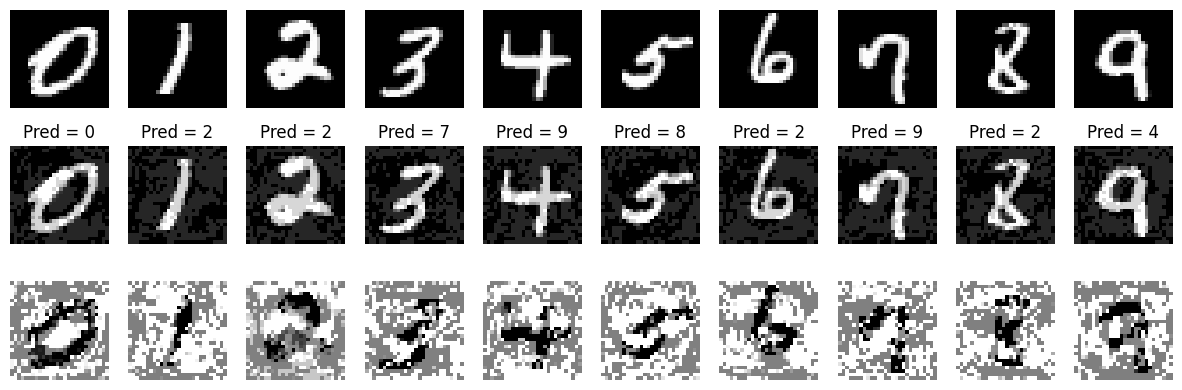

In [15]:
goal_acc = 0.1 # Exit loop when model accuracy on the adversarial data goes below this value
max_it = 200

X_test_adv = torch.tensor(X_test).to(device).requires_grad_(True)
target_class = 0

y_test_adv = np.zeros_like(y_test)
y_test_adv[:] = target_class
y_test_oh_adv = np.zeros_like(y_test_oh)
y_test_oh_adv[:,target_class] = 1

y_test_oh_adv_t = torch.tensor(y_test_oh_adv).to(device)

sigma = 0.01
for i in range(max_it):
  pred = model(X_test_adv)
  pred_class = np.argmax(pred.cpu().detach().numpy(),axis=1)
  acc = accuracy_score(y_test,pred_class)
  print(f'{i =}, {acc =:7.4f}')
  if acc < goal_acc:
     break
  loss = loss_function(pred, y_test_oh_t)
  loss.backward()
  grad_sign = torch.sign(X_test_adv.grad)
  noise = sigma*grad_sign
  X_test_adv.data = torch.clip(X_test_adv.data+noise,0,1)

print('Confusion matrix')
print(confusion_matrix(y_test,pred_class))

rs = [np.random.randint(0,len(sample[i])) for i in range(10)]
random_sel = [sample[i][r] for i,r in enumerate(rs)]
noise = X_test_adv.data.cpu().detach().numpy() - X_test
print(f'Mean absolute noise = {np.mean(np.abs(noise)) :7.4f}')
print(f'Max absolute noise = {np.max(np.abs(noise)) :7.4f}')

fig, ax = plt.subplots(3, 10, figsize=(15,5))
for i,s in enumerate(random_sel):
  ax[0,i].imshow(X_test[s].reshape(28,28), cmap = "gray")
  ax[0,i].axis("off")
  ax[1,i].imshow(X_test_noisy[s].reshape(28,28), cmap = "gray")
  ax[1,i].axis("off")
  ax[1,i].set_title(f'Pred = {pred_class[s]}')
  ax[2,i].imshow(noise[s].reshape(28,28), cmap = "gray")
  ax[2,i].axis("off")

### The Basic Iterative Method with targeted attacks

As with FGSM, we can target the noise to make the model predict a desired class for all images.


i =  0, acc = 0.0887
i =  1, acc = 0.0904
i =  2, acc = 0.0927
i =  3, acc = 0.0967
i =  4, acc = 0.1012
i =  5, acc = 0.1087
i =  6, acc = 0.1186
i =  7, acc = 0.1363
i =  8, acc = 0.1603
i =  9, acc = 0.1902
i = 10, acc = 0.2312
i = 11, acc = 0.2788
i = 12, acc = 0.3310
i = 13, acc = 0.3903
i = 14, acc = 0.4556
i = 15, acc = 0.5133
i = 16, acc = 0.5747
i = 17, acc = 0.6297
i = 18, acc = 0.6844
i = 19, acc = 0.7329
i = 20, acc = 0.7769
i = 21, acc = 0.8136
i = 22, acc = 0.8464
i = 23, acc = 0.8739
i = 24, acc = 0.8959
i = 25, acc = 0.9177
Confusion matrix
[[   0    0    0    0    0    0    0    0    0    0]
 [   0    0    0    0    0    0    0    0    0    0]
 [   0    0    0    0    0    0    0    0    0    0]
 [   0    0    0    0    0    0    0    0    0    0]
 [   0    0    0    0    0    0    0    0    0    0]
 [ 185    0   78  114    5 9177  118    2  312    9]
 [   0    0    0    0    0    0    0    0    0    0]
 [   0    0    0    0    0    0    0    0    0    0]
 [   0    0  

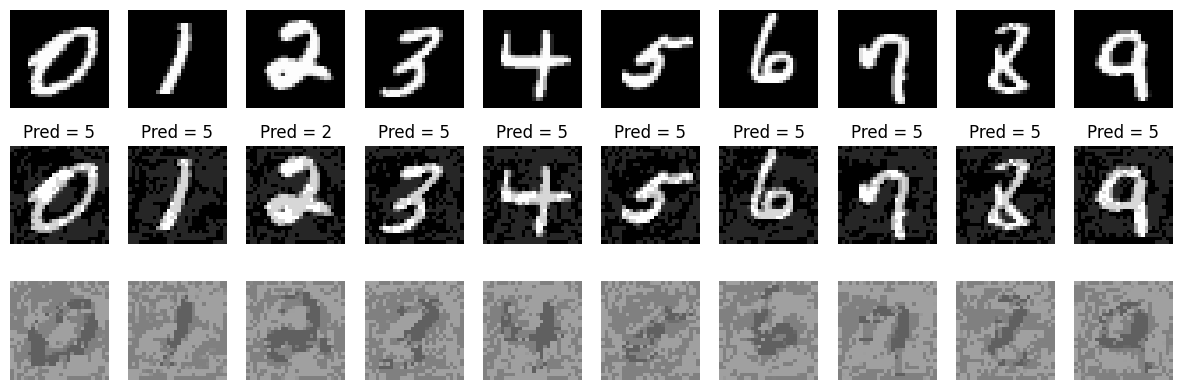

In [16]:
X_test_adv = torch.tensor(X_test).to(device).requires_grad_(True)
target_class = 5
goal_acc = 0.9

y_test_adv = np.zeros_like(y_test) + target_class

y_test_oh_adv = np.zeros_like(y_test_oh)
y_test_oh_adv[:,target_class] = 1

y_test_oh_adv_t = torch.tensor(y_test_oh_adv).to(device)

pred = model(X_test_gr)
loss = loss_function(pred, y_test_oh_adv_t)
loss.backward()
grad_sign = torch.sign(X_test_gr.grad).cpu().detach().numpy()

sigma = 0.005

for i in range(max_it):
  pred = model(X_test_adv)
  pred_class = np.argmax(pred.cpu().detach().numpy(),axis=1)
  acc = accuracy_score(y_test_adv,pred_class)
  print(f'{i =:3}, {acc =:7.4f}')
  if acc > goal_acc:
     break
  loss = loss_function(pred, y_test_oh_adv_t)
  loss.backward()
  grad_sign = torch.sign(X_test_adv.grad)
  noise = -sigma*grad_sign
  X_test_adv.data = torch.clip(X_test_adv.data+noise,0,1)

print('Confusion matrix')
print(confusion_matrix(y_test_adv,pred_class,labels=np.arange(10)))

noise = X_test_adv.data.cpu().detach().numpy() - X_test
print(f'Mean absolute noise = {np.mean(np.abs(noise)) :7.4f}')
print(f'Max absolute noise = {np.max(np.abs(noise)) :7.4f}')

fig, ax = plt.subplots(3, 10, figsize=(15,5))
for i,s in enumerate(random_sel):
  ax[0,i].imshow(X_test[s].reshape(28,28), vmin=0, vmax=1, cmap = "gray")
  ax[0,i].axis("off")
  ax[1,i].imshow(X_test_noisy[s].reshape(28,28), vmin=0, vmax=1, cmap = "gray")
  ax[1,i].axis("off")
  ax[1,i].set_title(f'Pred = {pred_class[s]}')
  ax[2,i].imshow(noise[s].reshape(28,28),  vmin=-.5, vmax=.5, cmap = "gray")
  ax[2,i].axis("off")

## Additional Two-Hidden-Layer Network Variant


This architecture variant is retained because it is technically distinct from the primary baseline.


ffnn(
  (dense1): Linear(in_features=784, out_features=500, bias=True)
  (dense2): Linear(in_features=500, out_features=500, bias=True)
  (dense3): Linear(in_features=500, out_features=10, bias=True)
)
Epoch  1 loss = 0.454877 test loss = 0.203783 train accuracy = 0.8826 test accuracy = 0.9387 
Epoch  2 loss = 0.169894 test loss = 0.127749 train accuracy = 0.9509 test accuracy = 0.9619 
Epoch  3 loss = 0.109516 test loss = 0.098115 train accuracy = 0.9674 test accuracy = 0.9695 
Epoch  4 loss = 0.079641 test loss = 0.083955 train accuracy = 0.9764 test accuracy = 0.9737 
Epoch  5 loss = 0.058863 test loss = 0.076403 train accuracy = 0.9829 test accuracy = 0.9752 
Epoch  6 loss = 0.042936 test loss = 0.072575 train accuracy = 0.9875 test accuracy = 0.9775 
Epoch  7 loss = 0.033817 test loss = 0.067500 train accuracy = 0.9900 test accuracy = 0.9792 
Epoch  8 loss = 0.026443 test loss = 0.068470 train accuracy = 0.9921 test accuracy = 0.9795 
Epoch  9 loss = 0.020226 test loss = 0.069188 

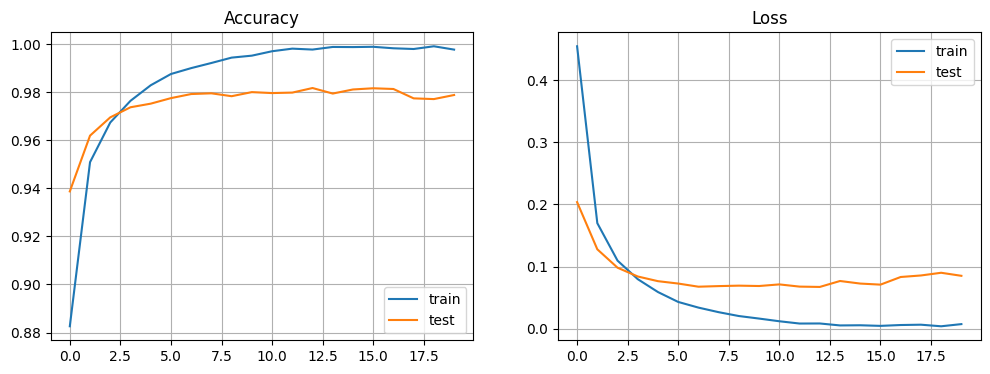

In [18]:
class ffnn(nn.Module):
  def __init__(self, n_inputs, n_hidden1, n_hidden2, n_outputs):
    super(ffnn,self).__init__()
    self.dense1 = nn.Linear(n_inputs, n_hidden1)
    self.dense2 = nn.Linear(n_hidden1, n_hidden2)
    self.dense3 = nn.Linear(n_hidden2, n_outputs)

  def forward(self,x):
    x = self.dense1(x)
    x = F.relu(x)
    x = self.dense2(x)
    x = F.relu(x)
    out = self.dense3(x)
    return out

model = ffnn(784, 500, 500, 10).to(device)
print(model)

loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 20
batch_size = 500
size = X_train.shape[0]
start_train = time.time()
loss_list, acc_list  = [], []
loss_list_tst, acc_list_tst  = [], []
n_batches = X_train.shape[0]//batch_size
for epoch in range(1,num_epochs+1):
  pred_train = np.zeros(size,dtype= np.int32)
  batch_num = np.random.permutation(size)//batch_size
  sum_loss = 0
  for i in range(n_batches):
    # Convert numpy arrays to tensors and move to device for training batch
    X_batch = torch.tensor(X_train[batch_num==i]).to(device)
    y_batch = torch.tensor(y_train_oh[batch_num==i]).to(device)

    pred = model(X_batch)
    pred_train[batch_num==i] = np.argmax(pred.cpu().detach().numpy(),axis=1)
    loss = loss_function(pred, y_batch)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
    sum_loss+=loss.item()

  loss_list.append(batch_size*sum_loss/size)
  acc_list.append(accuracy_score(y_train,pred_train))

  # Convert X_test and y_test_oh to tensors and move to device for evaluation
  X_test_t = torch.tensor(X_test).to(device)
  y_test_oh_t = torch.tensor(y_test_oh).to(device)

  pred_test = model(X_test_t)
  loss_tst = loss_function(pred_test, y_test_oh_t).item()
  loss_list_tst.append(loss_tst)
  acc_list_tst.append(accuracy_score(y_test,np.argmax(pred_test.cpu().detach().numpy(),axis=1)))

  print(f'Epoch {epoch:2} loss = {loss_list[-1]:.6f} test loss = {loss_list_tst[-1]:.6f} train accuracy = {acc_list[-1]:.4f} test accuracy = {acc_list_tst[-1]:.4f} ')

end_train = time.time()
print('Elapsed time training= {:.4f} secs'.format(end_train-start_train))
history = {'accuracy':acc_list, 'loss': loss_list, 'val_accuracy': acc_list_tst, 'val_loss': loss_list_tst}
plot_results(history)

## Additional Random-Noise Sweep


The following source experiment uses its original noise-level sequence and threshold logic.


In [19]:
noise_levels = np.linspace(0, 1, 20)
noise_levels

array([0.        , 0.05263158, 0.10526316, 0.15789474, 0.21052632,
       0.26315789, 0.31578947, 0.36842105, 0.42105263, 0.47368421,
       0.52631579, 0.57894737, 0.63157895, 0.68421053, 0.73684211,
       0.78947368, 0.84210526, 0.89473684, 0.94736842, 1.        ])

Add increasingly large random noise to the images in the test set and evaluate the accuracy of the model.

When the accuracy falls below 0.5, display some of the noisy images.


Noise level: 0.00, Accuracy: 0.9788
Noise level: 0.05, Accuracy: 0.9774
Noise level: 0.11, Accuracy: 0.9672
Noise level: 0.16, Accuracy: 0.9396
Noise level: 0.21, Accuracy: 0.8745
Noise level: 0.26, Accuracy: 0.7944
Noise level: 0.32, Accuracy: 0.7229
Noise level: 0.37, Accuracy: 0.6507
Noise level: 0.42, Accuracy: 0.5833
Noise level: 0.47, Accuracy: 0.5267
Noise level: 0.53, Accuracy: 0.4799
Accuracy dropped below 0.5 at noise level 0.53. Displaying some noisy images.


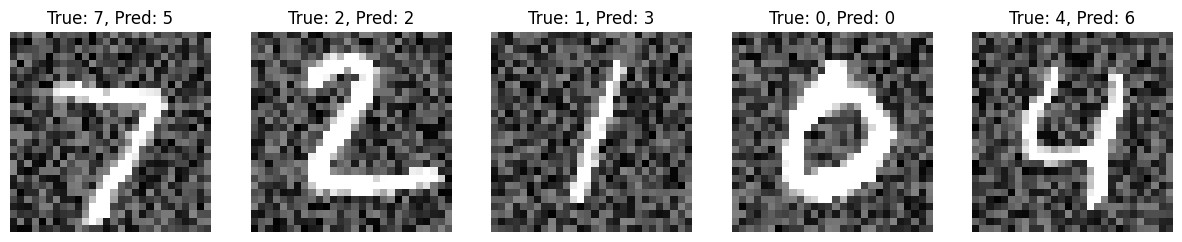

In [21]:
accuracy_threshold = 0.5
noise_levels = np.linspace(0, 1, 20)

for noise_level in noise_levels:

  noise = noise_level * np.random.random(X_test.shape)
  noisy_X_test_np = X_test + noise
  noisy_X_test_np = np.clip(noisy_X_test_np, 0, 1)
  noisy_X_test = torch.tensor(noisy_X_test_np).to(device).float()


  with torch.no_grad():
    pred_noisy_test = model(noisy_X_test)
    noisy_test_accuracy = accuracy_score(y_test, np.argmax(pred_noisy_test.cpu().numpy(), axis=1))

  print(f"Noise level: {noise_level:.2f}, Accuracy: {noisy_test_accuracy:.4f}")


  if noisy_test_accuracy < accuracy_threshold:
    print(f"Accuracy dropped below {accuracy_threshold} at noise level {noise_level:.2f}. Displaying some noisy images.")

    num_images_to_display = 5
    imgs = noisy_X_test[:num_images_to_display].cpu().numpy().reshape(-1, 28, 28)

    true_labels = y_test[:num_images_to_display]
    predicted_labels = np.argmax(pred_noisy_test[:num_images_to_display].cpu().numpy(), axis=1)

    title = [f"True: {true_labels[i]}, Pred: {predicted_labels[i]}" for i in range(num_images_to_display)]

    fig, ax = plt.subplots(ncols=num_images_to_display, figsize=(15, 3))
    for i, img in enumerate(imgs):
      ax[i].imshow(img, cmap='gray', vmin=0, vmax=1)
      ax[i].set_axis_off()
      ax[i].set_title(title[i])
    plt.show()
    break

In [22]:

for i, img in enumerate(imgs):
  ax[i].imshow(img,cmap='gray', vmin=0, vmax=1)
  ax[i].set_axis_off()
  ax[i].set_title(title[i])
ax[2].imshow(img)
plt.show()

## Additional FGSM Accuracy-Threshold Experiment


Now we'll further reduce the target accuracy and observe the required amount of noise to make classification accuracy worse than random guessing (less than 0.1 for MNIST).


sigma = 0.0050, acc = 0.9698
sigma = 0.0100, acc = 0.9560
sigma = 0.0150, acc = 0.9354
sigma = 0.0200, acc = 0.9050
sigma = 0.0250, acc = 0.8603
sigma = 0.0300, acc = 0.7993
sigma = 0.0350, acc = 0.7223
sigma = 0.0400, acc = 0.6497
sigma = 0.0450, acc = 0.5842
sigma = 0.0500, acc = 0.5299
sigma = 0.0550, acc = 0.4824
sigma = 0.0600, acc = 0.4430
sigma = 0.0650, acc = 0.4056
sigma = 0.0700, acc = 0.3699
sigma = 0.0750, acc = 0.3382
sigma = 0.0800, acc = 0.3077
sigma = 0.0850, acc = 0.2780
Mean absolute noise =  0.0482
Max absolute noise =  0.0850


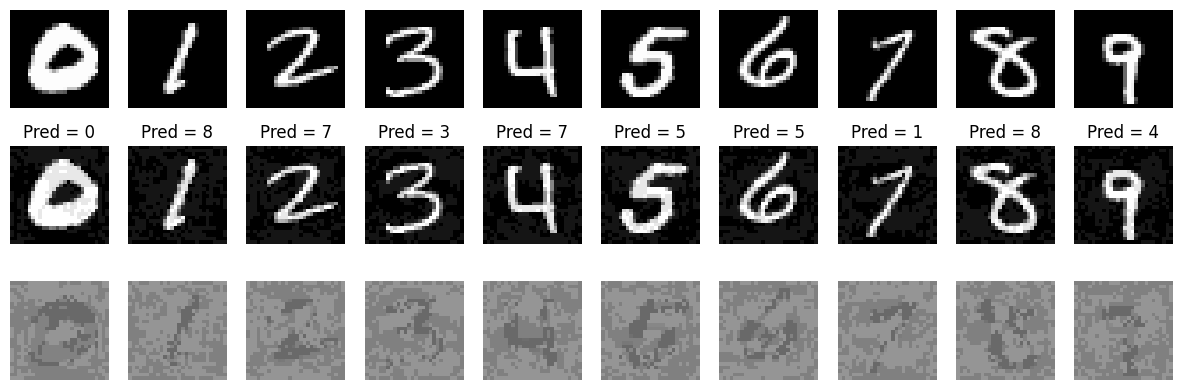

In [26]:
goal_acc = 0.3 # Exit loop when model accuracy on the adversarial data goes below this value
max_it = 200

# Re-calculate grad_sign to ensure it's a numpy array in the current scope
X_test_gr = torch.tensor(X_test).to(device).requires_grad_(True)
pred = model(X_test_gr)
loss = loss_function(pred, y_test_oh_t)
loss.backward()
grad_sign = np.sign(X_test_gr.grad.cpu().detach().numpy()) # FIX: Apply np.sign to the gradients

for i in range(1,max_it):
  sigma = i/max_it # Sigma goes from 0.01 to 0.99 if max_it = 100
  noise = sigma*grad_sign
  X_test_noisy = np.clip(X_test+noise,0,1) # Keep input in the 0 to 1 range
  pred = model(torch.tensor(X_test_noisy).to(device))
  pred_class = np.argmax(pred.cpu().detach().numpy(),axis=1)
  acc = accuracy_score(y_test,pred_class)
  print(f'{sigma =:7.4f}, {acc =:7.4f}')
  if acc < goal_acc:
     break

# Select random images to display
rs = [np.random.randint(0,len(sample[i])) for i in range(10)]
random_sel = [sample[i][rs[i]] for i in range(10)] # Corrected line: use rs[i] as index
noise = X_test_noisy - X_test
print(f'Mean absolute noise = {np.mean(np.abs(noise)) :7.4f}')
print(f'Max absolute noise = {np.max(np.abs(noise)) :7.4f}')

fig, ax = plt.subplots(3, 10, figsize=(15,5))
for i,s in enumerate(random_sel):
  ax[0,i].imshow(X_test[s].reshape(28,28), vmin=0, vmax=1, cmap = "gray")
  ax[0,i].axis("off")
  ax[1,i].imshow(X_test_noisy[s].reshape(28,28), vmin=0, vmax=1, cmap = "gray")
  ax[1,i].axis("off")
  ax[1,i].set_title(f'Pred = {pred_class[s]}')
  ax[2,i].imshow(noise[s].reshape(28,28),  vmin=-.5, vmax=.5, cmap = "gray")
  ax[2,i].axis("off")

## Additional Targeted FGSM Experiment: Target Class 0


Targeted attacks.

We can also target the noise to make the model predict a desired class for all images.

In this case, we modify the target (for example to predict '0' for all examples) and apply noise to decrease the loss for that target.


sigma = 0.0100, acc = 0.1007
sigma = 0.0200, acc = 0.1038
sigma = 0.0300, acc = 0.1103
sigma = 0.0400, acc = 0.1222
sigma = 0.0500, acc = 0.1427
sigma = 0.0600, acc = 0.1736
sigma = 0.0700, acc = 0.2167
sigma = 0.0800, acc = 0.2711
sigma = 0.0900, acc = 0.3306
sigma = 0.1000, acc = 0.3890
sigma = 0.1100, acc = 0.4445
sigma = 0.1200, acc = 0.4891
sigma = 0.1300, acc = 0.5246
Mean absolute noise =  0.0812
Max absolute noise =  0.1300


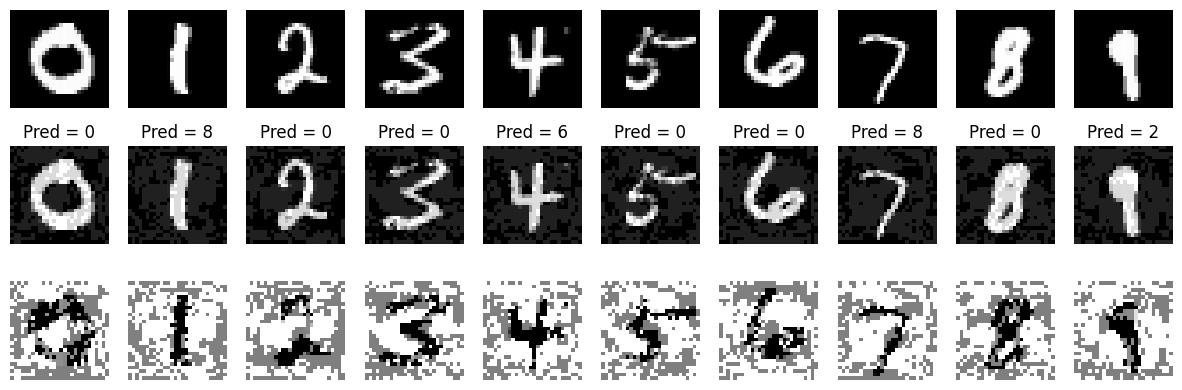

In [27]:
X_test_gr = torch.tensor(X_test).to(device).requires_grad_(True)
target_class = 0
goal_acc = 0.5

y_test_adv = np.zeros_like(y_test)
y_test_adv[:] = target_class
y_test_oh_adv = np.zeros_like(y_test_oh)
y_test_oh_adv[:,target_class] = 1

y_test_oh_adv_t = torch.tensor(y_test_oh_adv).to(device)

pred = model(X_test_gr)
loss = loss_function(pred, y_test_oh_adv_t)
loss.backward()
grad_sign = torch.sign(X_test_gr.grad).cpu().detach().numpy()

for i in range(1,100):
  sigma = i/100
  noise = -sigma*grad_sign
  X_test_noisy = np.clip(X_test+noise,0,1)
  pred = model(torch.tensor(X_test_noisy).to(device))
  pred_class = np.argmax(pred.cpu().detach().numpy(),axis=1)
  acc = accuracy_score(y_test_adv,pred_class)
  print(f'{sigma =:7.4f}, {acc =:7.4f}')
  if acc>goal_acc:
    break

noise = X_test_noisy - X_test
print(f'Mean absolute noise = {np.mean(np.abs(noise)) :7.4f}')
print(f'Max absolute noise = {np.max(np.abs(noise)) :7.4f}')

rs = [np.random.randint(0,len(sample[i])) for i in range(10)]
random_sel = [sample[i][r] for i,r in enumerate(rs)]
noise = X_test_noisy - X_test

fig, ax = plt.subplots(3, 10, figsize=(15,5))
for i,s in enumerate(random_sel):
  ax[0,i].imshow(X_test[s].reshape(28,28), cmap = "gray")
  ax[0,i].axis("off")
  ax[1,i].imshow(X_test_noisy[s].reshape(28,28), cmap = "gray")
  ax[1,i].axis("off")
  ax[1,i].set_title(f'Pred = {pred_class[s]}')
  ax[2,i].imshow(noise[s].reshape(28,28), cmap = "gray")
  ax[2,i].axis("off")

## Additional Targeted Iterative Experiment: Target Class 8


i =  0, acc = 0.0986
i =  1, acc = 0.1015
i =  2, acc = 0.1063
i =  3, acc = 0.1137
i =  4, acc = 0.1264
i =  5, acc = 0.1480
i =  6, acc = 0.1845
i =  7, acc = 0.2356
i =  8, acc = 0.2882
i =  9, acc = 0.3366
i = 10, acc = 0.3867
i = 11, acc = 0.4377
i = 12, acc = 0.4907
i = 13, acc = 0.5434
i = 14, acc = 0.5922
i = 15, acc = 0.6410
i = 16, acc = 0.6907
i = 17, acc = 0.7303
i = 18, acc = 0.7694
i = 19, acc = 0.8041
i = 20, acc = 0.8325
i = 21, acc = 0.8536
i = 22, acc = 0.8730
i = 23, acc = 0.8898
i = 24, acc = 0.9057
i = 25, acc = 0.9179
i = 26, acc = 0.9282
i = 27, acc = 0.9359
i = 28, acc = 0.9458
i = 29, acc = 0.9525
Mean absolute noise =  0.0832
Max absolute noise =  0.1450


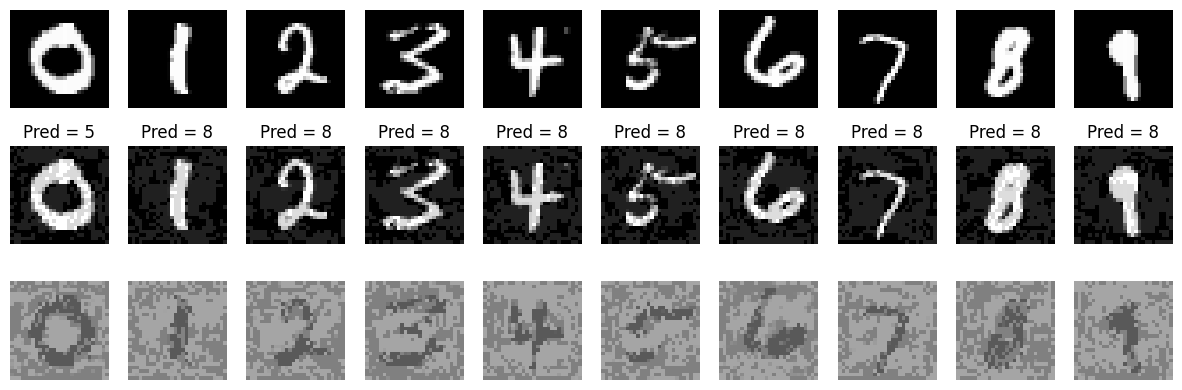

In [28]:
X_test_adv = torch.tensor(X_test).to(device).requires_grad_(True)
target_class = 8
goal_acc = 0.95

y_test_adv = np.zeros_like(y_test) + target_class

y_test_oh_adv = np.zeros_like(y_test_oh)
y_test_oh_adv[:,target_class] = 1

y_test_oh_adv_t = torch.tensor(y_test_oh_adv).to(device)

pred = model(X_test_gr)
loss = loss_function(pred, y_test_oh_adv_t)
loss.backward()
grad_sign = torch.sign(X_test_gr.grad).cpu().detach().numpy()

sigma = 1/max_it
for i in range(max_it):
  pred = model(X_test_adv)
  pred_class = np.argmax(pred.cpu().detach().numpy(),axis=1)
  acc = accuracy_score(y_test_adv,pred_class)
  print(f'{i =:3}, {acc =:7.4f}')
  if acc > goal_acc:
     break
  loss = loss_function(pred, y_test_oh_adv_t)
  loss.backward()
  grad_sign = torch.sign(X_test_adv.grad)
  noise = -sigma*grad_sign
  X_test_adv.data = torch.clip(X_test_adv.data+noise,0,1)

noise = X_test_adv.data.cpu().detach().numpy() - X_test
print(f'Mean absolute noise = {np.mean(np.abs(noise)) :7.4f}')
print(f'Max absolute noise = {np.max(np.abs(noise)) :7.4f}')

fig, ax = plt.subplots(3, 10, figsize=(15,5))
for i,s in enumerate(random_sel):
  ax[0,i].imshow(X_test[s].reshape(28,28), vmin=0, vmax=1, cmap = "gray")
  ax[0,i].axis("off")
  ax[1,i].imshow(X_test_noisy[s].reshape(28,28), vmin=0, vmax=1, cmap = "gray")
  ax[1,i].axis("off")
  ax[1,i].set_title(f'Pred = {pred_class[s]}')
  ax[2,i].imshow(noise[s].reshape(28,28),  vmin=-.5, vmax=.5, cmap = "gray")
  ax[2,i].axis("off")